<a href="https://colab.research.google.com/github/AFK-Abhinav/Flower-Species-Classification-with-MobileNetV2/blob/main/Flower_Species_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import random
import shutil
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TensorFlow version : {tf.__version__}")
gpus = tf.config.list_physical_devices("GPU")
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"GPU detected       : {gpus[0].name}  ✅")
else:
    print("No GPU detected — running on CPU  ⚠️  (training will be slower)")

print("\nAll libraries imported successfully ✅")

TensorFlow version : 2.20.0
No GPU detected — running on CPU  ⚠️  (training will be slower)

All libraries imported successfully ✅


In [ ]:
import os
import shutil
import numpy as np
from pathlib import Path
import tensorflow as tf

os.system("pip install -q tensorflow-datasets")
import tensorflow_datasets as tfds

WORK_DIR   = Path("/content/data")
TRAIN_DIR  = WORK_DIR / "train"
VAL_DIR    = WORK_DIR / "val"
SEED       = 42

print("📥 Downloading tf_flowers dataset (automatic, no login required)...")

(ds_train_raw, ds_val_raw), info = tfds.load(
    "tf_flowers",
    split=["train[:80%]", "train[80%:]"],
    as_supervised=True,
    with_info=True,
    shuffle_files=True,
)

CLASS_NAMES = info.features["label"].names
NUM_CLASSES = info.features["label"].num_classes
print(f"\n✅ Download complete!")
print(f"   Classes ({NUM_CLASSES}): {CLASS_NAMES}")
print(f"   Train samples : {tf.data.experimental.cardinality(ds_train_raw).numpy()}")
print(f"   Val samples   : {tf.data.experimental.cardinality(ds_val_raw).numpy()}")

def save_split_to_disk(dataset, root_dir, split_name):
    root_dir = Path(root_dir)
    if root_dir.exists():
        shutil.rmtree(root_dir)
    for cls in CLASS_NAMES:
        (root_dir / cls).mkdir(parents=True, exist_ok=True)

    counters = {cls: 0 for cls in CLASS_NAMES}
    for image, label in dataset:
        cls_name = CLASS_NAMES[int(label.numpy())]
        img_path = root_dir / cls_name / f"{counters[cls_name]:05d}.jpg"
        encoded = tf.image.encode_jpeg(tf.cast(image, tf.uint8), quality=90)
        tf.io.write_file(str(img_path), encoded)
        counters[cls_name] += 1

    total = sum(counters.values())
    print(f"\n📂 {split_name} set saved → {root_dir}")
    for cls, cnt in counters.items():
        print(f"   {cls:<14}: {cnt:4d} images")
    print(f"   Total         : {total} images")

print("\nSaving images to disk (this takes ~60–90 seconds)...")
save_split_to_disk(ds_train_raw, TRAIN_DIR, "Train")
save_split_to_disk(ds_val_raw,   VAL_DIR,   "Validation")

print("\nData pipeline ready — no API key needed ✅")

📥 Downloading tf_flowers dataset (automatic, no login required)...

✅ Download complete!
   Classes (5): ['dandelion', 'daisy', 'tulips', 'sunflowers', 'roses']
   Train samples : 2936
   Val samples   : 734

Saving images to disk (this takes ~60–90 seconds)...

📂 Train set saved → /content/data/train
   dandelion     :  739 images
   daisy         :  513 images
   tulips        :  613 images
   sunflowers    :  561 images
   roses         :  510 images
   Total         : 2936 images

📂 Validation set saved → /content/data/val
   dandelion     :  159 images
   daisy         :  120 images
   tulips        :  186 images
   sunflowers    :  138 images
   roses         :  131 images
   Total         : 734 images

Data pipeline ready — no API key needed ✅


Found 2936 files belonging to 5 classes.
Found 734 files belonging to 5 classes.
Class names : ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']
Num classes : 5

Batch shape  : (16, 128, 128, 3)
Labels shape : (16, 5)


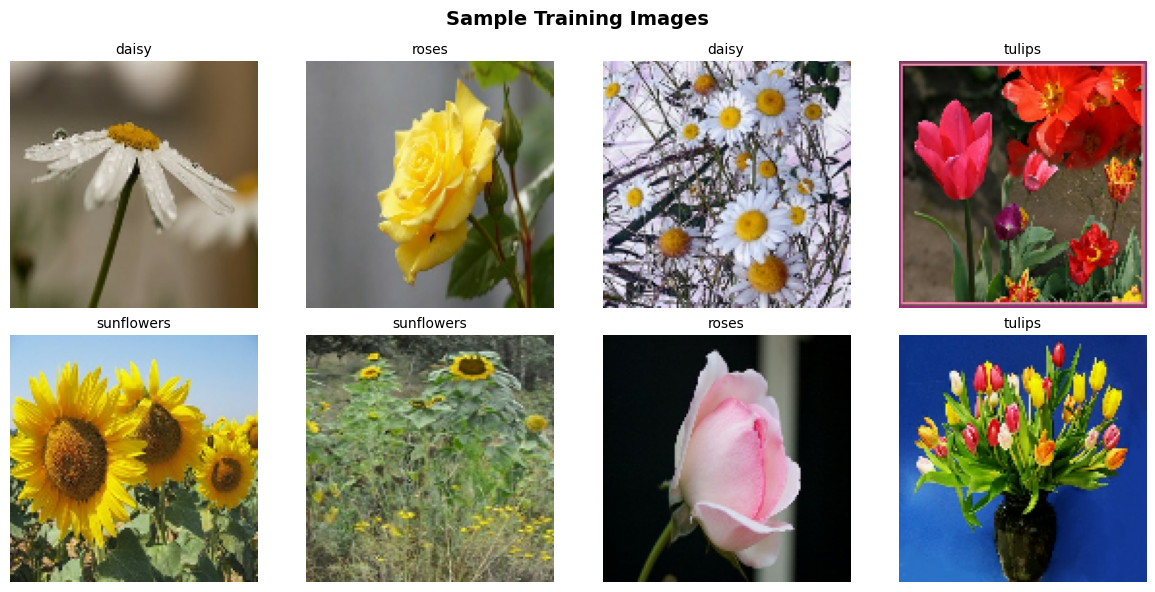

Data pipeline verified ✅


In [ ]:
IMG_SIZE    = (128, 128)
BATCH_SIZE  = 16
AUTOTUNE    = tf.data.AUTOTUNE

TRAIN_DIR = "/content/data/train"
VAL_DIR   = "/content/data/val"

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=True,
    seed=SEED,
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False,
)

CLASS_NAMES = train_ds.class_names
NUM_CLASSES = len(CLASS_NAMES)
print(f"Class names : {CLASS_NAMES}")
print(f"Num classes : {NUM_CLASSES}")

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds   = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

images, labels = next(iter(train_ds))
print(f"\nBatch shape  : {images.shape}")
print(f"Labels shape : {labels.shape}")

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
fig.suptitle("Sample Training Images", fontsize=14, fontweight="bold")
for ax, img, lbl in zip(axes.flat, images[:8], labels[:8]):
    ax.imshow(img.numpy().astype("uint8"))
    ax.set_title(CLASS_NAMES[np.argmax(lbl)], fontsize=10)
    ax.axis("off")
plt.tight_layout()
plt.show()
print("Data pipeline verified ✅")

In [ ]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.10),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10),
], name="data_augmentation")

preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

base_model = MobileNetV2(
    input_shape=(*IMG_SIZE, 3),
    include_top=False,
    weights="imagenet",
)
base_model.trainable = False
print(f"Base model params (frozen)    : {base_model.count_params():,}")

inputs = keras.Input(shape=(*IMG_SIZE, 3), name="input_image")

x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D(name="gap")(x)
x = layers.Dense(256, activation="relu", name="dense_256")(x)
x = layers.Dropout(0.4, name="dropout")(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax", name="predictions")(x)

model = keras.Model(inputs, outputs, name="LandmarkNet_MobileV2")

model.summary()
trainable     = sum(tf.size(w).numpy() for w in model.trainable_weights)
non_trainable = sum(tf.size(w).numpy() for w in model.non_trainable_weights)
print(f"\nTrainable params     : {trainable:,}")
print(f"Non-trainable params : {non_trainable:,}")
print("\nModel architecture built ✅")

Base model params (frozen)    : 2,257,984


Model: "LandmarkNet_MobileV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_1 (Subtract)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_256 (Dense)               │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,587,205 (9.87 MB)

 Trainable params: 329,221 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)


Trainable params     : 329,221
Non-trainable params : 2,257,984

Model architecture built ✅


In [ ]:
LEARNING_RATE = 1e-3
EPOCHS        = 15

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=["accuracy"],
)

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True,
        verbose=1,
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1,
    ),
]

print("🚀 Starting training...\n")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1,
)

print("\nTraining complete ✅")

🚀 Starting training...

Epoch 1/15
184/184 ━━━━━━━━━━━━━━━━━━━━ 66s 320ms/step - accuracy: 0.7595 - loss: 0.8211 - val_accuracy: 0.8597 - val_loss: 0.5562 - learning_rate: 0.0010
Epoch 2/15
184/184 ━━━━━━━━━━━━━━━━━━━━ 76s 289ms/step - accuracy: 0.8484 - loss: 0.6094 - val_accuracy: 0.8774 - val_loss: 0.5118 - learning_rate: 0.0010
Epoch 3/15
184/184 ━━━━━━━━━━━━━━━━━━━━ 51s 275ms/step - accuracy: 0.8668 - loss: 0.5626 - val_accuracy: 0.8787 - val_loss: 0.5147 - learning_rate: 0.0010
Epoch 4/15
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step - accuracy: 0.9008 - loss: 0.5050
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
184/184 ━━━━━━━━━━━━━━━━━━━━ 50s 273ms/step - accuracy: 0.8937 - loss: 0.5116 - val_accuracy: 0.8787 - val_loss: 0.5191 - learning_rate: 0.0010
Epoch 5/15
184/184 ━━━━━━━━━━━━━━━━━━━━ 81s 268ms/step - accuracy: 0.9125 - loss: 0.4737 - val_accuracy: 0.8910 - val_loss: 0.4894 - learning_rate: 5.0000e-04
Epoch 6/15
184/184 ━━━━━━━━━━━━━━━━━━━━ 85s 

  Final Validation Loss     : 0.4726
  Final Validation Accuracy : 90.19%

Per-class Accuracy:
  Class           Correct    Total    Acc %
  ----------------------------------------
  daisy               107      120    89.2%
  dandelion           147      159    92.5%
  roses               114      131    87.0%
  sunflowers          126      138    91.3%
  tulips              168      186    90.3%


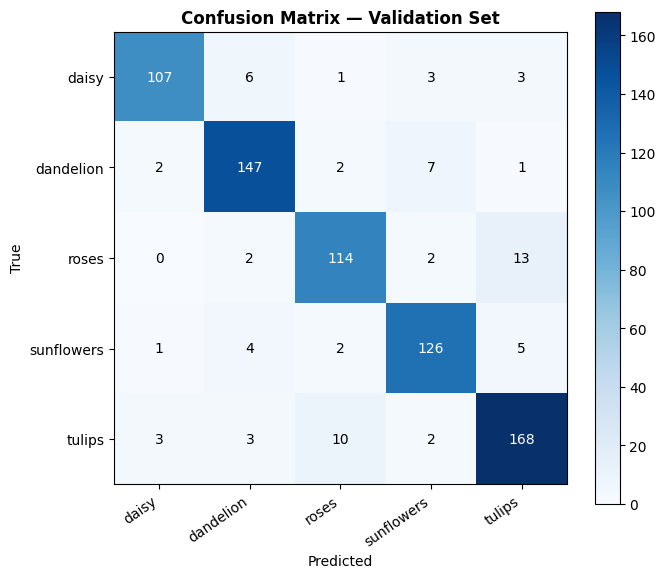


Evaluation complete ✅


In [ ]:
import numpy as np

val_loss, val_acc = model.evaluate(val_ds, verbose=0)
print("=" * 45)
print(f"  Final Validation Loss     : {val_loss:.4f}")
print(f"  Final Validation Accuracy : {val_acc * 100:.2f}%")
print("=" * 45)

all_true, all_pred = [], []

for images_batch, labels_batch in val_ds:
    preds = model.predict(images_batch, verbose=0)
    all_true.extend(np.argmax(labels_batch.numpy(), axis=1))
    all_pred.extend(np.argmax(preds, axis=1))

all_true = np.array(all_true)
all_pred = np.array(all_pred)

conf_matrix = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=int)
for t, p in zip(all_true, all_pred):
    conf_matrix[t][p] += 1

print("\nPer-class Accuracy:")
print(f"  {'Class':<14}  {'Correct':>7}  {'Total':>7}  {'Acc %':>7}")
print("  " + "-" * 40)
for i, cls in enumerate(CLASS_NAMES):
    correct = conf_matrix[i, i]
    total   = conf_matrix[i].sum()
    acc_pct = 100 * correct / total if total > 0 else 0
    print(f"  {cls:<14}  {correct:>7}  {total:>7}  {acc_pct:>6.1f}%")

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(conf_matrix, cmap="Blues")
ax.set_xticks(range(NUM_CLASSES))
ax.set_xticklabels(CLASS_NAMES, rotation=35, ha="right")
ax.set_yticks(range(NUM_CLASSES))
ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion Matrix — Validation Set", fontweight="bold")
plt.colorbar(im, ax=ax)
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        ax.text(j, i, conf_matrix[i, j], ha="center", va="center",
                color="white" if conf_matrix[i, j] > conf_matrix.max() / 2 else "black",
                fontsize=10)
plt.tight_layout()
plt.show()
print("\nEvaluation complete ✅")

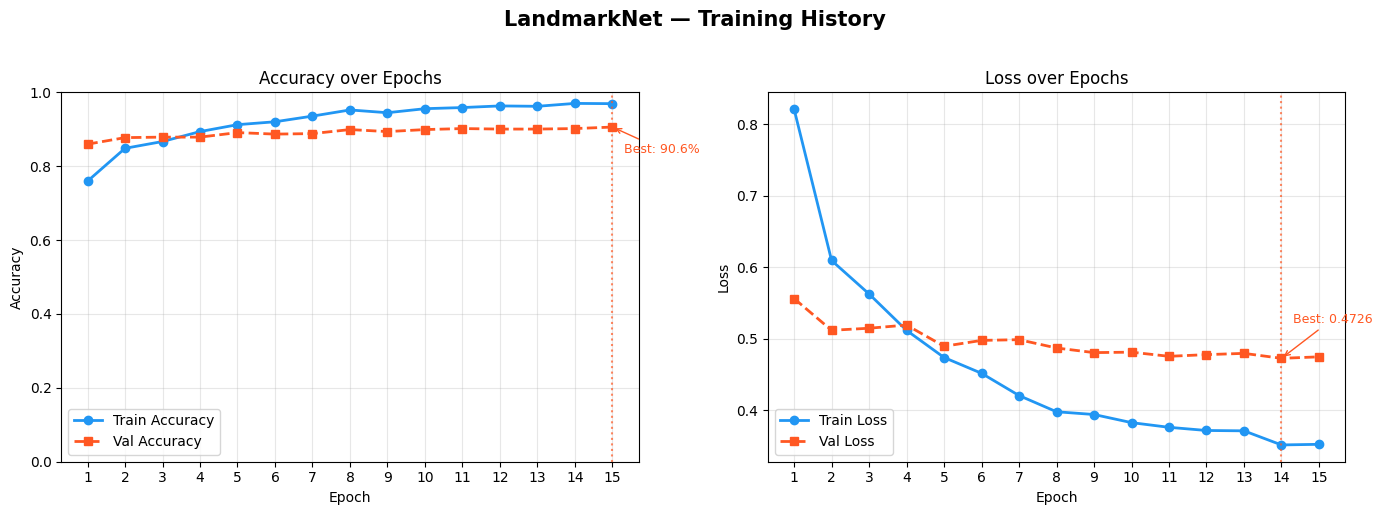

Training curves saved to /content/training_curves.png ✅


In [ ]:
epochs_ran = len(history.history["loss"])
epoch_axis = range(1, epochs_ran + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("LandmarkNet — Training History", fontsize=15, fontweight="bold", y=1.02)

ax1.plot(epoch_axis, history.history["accuracy"], "o-", color="#2196F3", lw=2, label="Train Accuracy")
ax1.plot(epoch_axis, history.history["val_accuracy"], "s--", color="#FF5722", lw=2, label="Val Accuracy")
ax1.set_title("Accuracy over Epochs")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy")
ax1.set_ylim(0, 1)
ax1.set_xticks(epoch_axis)
ax1.legend()
ax1.grid(alpha=0.3)

best_val_acc_epoch = np.argmax(history.history["val_accuracy"]) + 1
best_val_acc_val   = max(history.history["val_accuracy"])
ax1.axvline(best_val_acc_epoch, color="#FF5722", linestyle=":", alpha=0.7)
ax1.annotate(f"Best: {best_val_acc_val*100:.1f}%",
             xy=(best_val_acc_epoch, best_val_acc_val),
             xytext=(best_val_acc_epoch + 0.3, best_val_acc_val - 0.07),
             arrowprops=dict(arrowstyle="->", color="#FF5722"),
             color="#FF5722", fontsize=9)

ax2.plot(epoch_axis, history.history["loss"], "o-", color="#2196F3", lw=2, label="Train Loss")
ax2.plot(epoch_axis, history.history["val_loss"], "s--", color="#FF5722", lw=2, label="Val Loss")
ax2.set_title("Loss over Epochs")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Loss")
ax2.set_xticks(epoch_axis)
ax2.legend()
ax2.grid(alpha=0.3)

best_val_loss_epoch = np.argmin(history.history["val_loss"]) + 1
best_val_loss_val   = min(history.history["val_loss"])
ax2.axvline(best_val_loss_epoch, color="#FF5722", linestyle=":", alpha=0.7)
ax2.annotate(f"Best: {best_val_loss_val:.4f}",
             xy=(best_val_loss_epoch, best_val_loss_val),
             xytext=(best_val_loss_epoch + 0.3, best_val_loss_val + 0.05),
             arrowprops=dict(arrowstyle="->", color="#FF5722"),
             color="#FF5722", fontsize=9)

plt.tight_layout()
plt.savefig("/content/training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Training curves saved to /content/training_curves.png ✅")

Testing on: /content/data/val/daisy/00000.jpg
True class: daisy



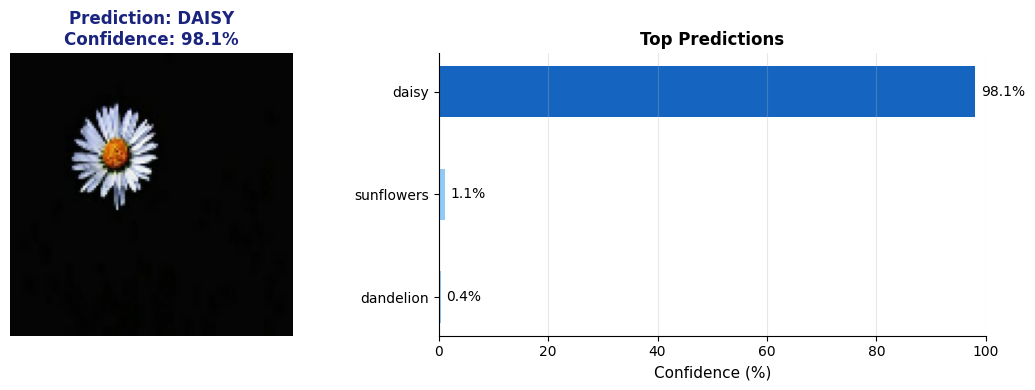


── Top Predictions ──────────────
  #1  daisy          98.1%  ███████████████████
  #2  sunflowers      1.1%  
  #3  dandelion       0.4%  

Inference pipeline working ✅


In [ ]:
import matplotlib.patches as mpatches

def predict_landmark(image_path: str, top_k: int = 3):
    img_raw = tf.io.read_file(image_path)
    img     = tf.image.decode_image(img_raw, channels=3, expand_animations=False)
    img     = tf.image.resize(img, IMG_SIZE)
    img_for_display = img.numpy().astype("uint8")

    img_batch = tf.expand_dims(img, 0)

    preds       = model.predict(img_batch, verbose=0)[0]
    top_indices = np.argsort(preds)[::-1][:top_k]
    top_classes = [CLASS_NAMES[i] for i in top_indices]
    top_confs   = [preds[i] * 100 for i in top_indices]

    fig, (ax_img, ax_bar) = plt.subplots(1, 2, figsize=(11, 4),
                                         gridspec_kw={"width_ratios": [1, 1.4]})

    ax_img.imshow(img_for_display)
    ax_img.set_title(f"Prediction: {top_classes[0].upper()}\nConfidence: {top_confs[0]:.1f}%",
                     fontsize=12, fontweight="bold", color="#1A237E")
    ax_img.axis("off")

    colors = ["#1565C0" if i == 0 else "#90CAF9" for i in range(top_k)]
    bars = ax_bar.barh(top_classes[::-1], top_confs[::-1], color=colors[::-1], height=0.5)
    ax_bar.set_xlim(0, 100)
    ax_bar.set_xlabel("Confidence (%)", fontsize=11)
    ax_bar.set_title("Top Predictions", fontsize=12, fontweight="bold")
    for bar, conf in zip(bars, top_confs[::-1]):
        ax_bar.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
                    f"{conf:.1f}%", va="center", fontsize=10)
    ax_bar.grid(axis="x", alpha=0.3)
    ax_bar.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    plt.show()

    print("\n── Top Predictions ──────────────")
    for rank, (cls, conf) in enumerate(zip(top_classes, top_confs), 1):
        bar_fill = "█" * int(conf / 5)
        print(f"  #{rank}  {cls:<12}  {conf:5.1f}%  {bar_fill}")

    return top_classes[0], top_confs[0]

test_class = CLASS_NAMES[0]
test_img_dir = Path(VAL_DIR) / test_class
test_img_path = str(sorted(test_img_dir.glob("*.jpg"))[0])
print(f"Testing on: {test_img_path}")
print(f"True class: {test_class}\n")

predicted_class, confidence = predict_landmark(test_img_path)

print("\nInference pipeline working ✅")